# KATL/KDAL V20 Half-Up Override Classifier V3

V3 keeps the regression's ordinary nearest half-up rounded bucket by default. Its binary target is
`1` only when changing to the opposite floor/ceil choice produces the settled 2°F bucket while the
default bucket loses; otherwise it is `0`. Same-bucket floor/ceil rows are non-actionable class `0`.

All rows are modeled. There are no boundary-distance windows. Model hyperparameters, Platt
calibration, and override threshold are selected in separate chronological windows before the next
outer year is evaluated.


## Environment and contracts


In [1]:
from pathlib import Path
import sys
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.calibration.round_override import (
    audit_round_override_system,
    build_round_override_frame,
    continuous_override_comparison,
    fit_round_override_system,
    predict_round_override,
    round_override_metrics,
    serializable_override_bundle,
)
from src.calibration.v19_bucket import crossfit_ridge_predictions

STATIONS = {
    "KATL": {
        "pipeline": PROJECT_ROOT / "data/calibration/station_stacking_v20_peak_timing",
        "peak": True,
        "continuous": PROJECT_ROOT / "data/calibration/station_continuous_residual_probability/KATL/KATL_forward_continuous_predictions.csv",
    },
    "KDAL": {
        "pipeline": PROJECT_ROOT / "data/calibration/station_stacking_v20_kdal_no_peak",
        "peak": False,
        "continuous": PROJECT_ROOT / "data/calibration/station_continuous_residual_probability/KDAL/KDAL_forward_continuous_predictions.csv",
    },
}
print(PROJECT_ROOT)


D:\dev\weather-research


## Build the bucket-aware override label


In [2]:
frames, sources, summaries = {}, {}, []
for station, config in STATIONS.items():
    features = pd.read_csv(config["pipeline"] / f"{station}_features.csv", low_memory=False)
    validation = pd.read_csv(config["pipeline"] / f"{station}_year_split_validation_predictions.csv")
    point = crossfit_ridge_predictions(validation)
    frame = build_round_override_frame(
        features, point, validation, include_peak_features=config["peak"]
    )
    frames[station] = frame
    sources[station] = {"features": features, "validation": validation, "point": point}
    summaries.append({
        "station": station,
        "rows": len(frame),
        "start": frame["contract_date"].min().date(),
        "end": frame["contract_date"].max().date(),
        "actionable_rate": frame["override_actionable"].mean(),
        "override_target_rate": frame["override_target"].mean(),
        "default_bucket_hit_rate": frame["default_bucket_win"].mean(),
    })
dataset_summary = pd.DataFrame(summaries)
dataset_summary


D:\dev\weather-research\src\calibration\round_direction.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["floor_degree_f"] = floor_degree
D:\dev\weather-research\src\calibration\round_direction.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["ceil_degree_f"] = ceil_degree
D:\dev\weather-research\src\calibration\round_direction.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

D:\dev\weather-research\src\calibration\round_override.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["alternative_bucket_win"] = frame["alternative_bucket_label"].eq(
D:\dev\weather-research\src\calibration\round_override.py:118: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["override_target"] = (
D:\dev\weather-research\src\calibration\round_override.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

,station,rows,start,end,actionable_rate,override_target_rate,default_bucket_hit_rate
0,KATL,1092,2023-01-01,2025-12-31,0.483516,0.155678,0.458791
1,KDAL,1091,2023-01-01,2025-12-31,0.468378,0.164986,0.451879


In [3]:
columns = [
    "contract_date", "point_prediction_f", "default_degree_f", "default_bucket_label",
    "alternative_degree_f", "alternative_bucket_label", "override_actionable",
    "actual_high_f", "actual_bucket_label", "default_bucket_win",
    "alternative_bucket_win", "override_target",
]
pd.concat([frame.assign(station=station).head(6) for station, frame in frames.items()])[["station", *columns]]


C:\Users\Faris Fadil Arifin\AppData\Local\Temp\ipykernel_42428\4014640068.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pd.concat([frame.assign(station=station).head(6) for station, frame in frames.items()])[["station", *columns]]


,station,contract_date,point_prediction_f,default_degree_f,default_bucket_label,alternative_degree_f,alternative_bucket_label,override_actionable,actual_high_f,actual_bucket_label,default_bucket_win,alternative_bucket_win,override_target
0,KATL,2023-01-01,67.913145,68,68-69,67,66-67,1,70.0,70-71,0,0,0
1,KATL,2023-01-02,68.126939,68,68-69,69,68-69,0,72.0,72-73,0,0,0
2,KATL,2023-01-03,71.071594,71,70-71,72,72-73,1,70.0,70-71,1,0,0
3,KATL,2023-01-04,70.117850,70,70-71,71,70-71,0,69.0,68-69,0,0,0
4,KATL,2023-01-05,61.642525,62,62-63,61,60-61,1,62.0,62-63,1,0,0
5,KATL,2023-01-06,57.044540,57,56-57,58,58-59,1,58.0,58-59,0,1,1
0,KDAL,2023-01-01,76.369405,76,76-77,77,76-77,0,76.0,76-77,1,1,0
1,KDAL,2023-01-03,67.568693,68,68-69,67,66-67,1,68.0,68-69,1,0,0
2,KDAL,2023-01-04,59.220302,59,58-59,60,60-61,1,58.0,58-59,1,0,0
3,KDAL,2023-01-05,59.616485,60,60-61,59,58-59,1,61.0,60-61,1,0,0


## Nested V3 training, calibration, and threshold selection


In [4]:
results = {}
for station, config in STATIONS.items():
    print(f"Training V3 {station}...")
    results[station] = fit_round_override_system(
        frames[station], station_id=station, include_peak_features=config["peak"]
    )
print("Training complete")


Training V3 KATL...


Training V3 KDAL...


Training complete


## Selected fold configurations


In [5]:
fold_states = pd.concat(
    [result["fold_states"].assign(station=station) for station, result in results.items()],
    ignore_index=True,
)
fold_states[[
    "station", "validation_year", "selected_family", "selected_model_params_json",
    "selected_actionable_weight", "override_threshold", "model_training_cutoff",
    "calibration_start", "calibration_cutoff", "policy_start", "policy_cutoff",
]]


,station,validation_year,selected_family,selected_model_params_json,selected_actionable_weight,override_threshold,model_training_cutoff,calibration_start,calibration_cutoff,policy_start,policy_cutoff
0,KATL,2024,logistic,"{""C"": 0.1}",1.0,0.500,2023-09-02,2023-09-03,2023-11-01,2023-11-02,2023-12-31
1,KATL,2025,catboost,"{""l2_regularization"": 10.0, ""learning_rate"": 0...",1.0,0.375,2024-09-02,2024-09-03,2024-11-01,2024-11-02,2024-12-31
2,KDAL,2024,catboost,"{""l2_regularization"": 10.0, ""learning_rate"": 0...",1.0,0.275,2023-09-02,2023-09-03,2023-11-01,2023-11-02,2023-12-31
3,KDAL,2025,catboost,"{""l2_regularization"": 20.0, ""learning_rate"": 0...",1.0,1.100,2024-09-02,2024-09-03,2024-11-01,2024-11-02,2024-12-31


## Honest 2024–2025 result


In [6]:
forward_metrics = pd.concat(
    [result["forward_metrics"].assign(station=station) for station, result in results.items()],
    ignore_index=True,
)
metric_columns = [
    "station", "period", "count", "override_target_rate", "mean_override_probability",
    "binary_log_loss", "brier", "ece", "roc_auc", "pr_auc", "actionable_count",
    "default_bucket_hit_rate", "final_bucket_hit_rate", "bucket_hit_rate_lift",
    "override_count", "override_precision", "override_recall", "recovered_losses",
    "damaged_wins", "net_recovered_wins", "recovery_damage_ratio",
]
forward_metrics[metric_columns]


,station,period,count,override_target_rate,mean_override_probability,binary_log_loss,brier,ece,roc_auc,pr_auc,...,default_bucket_hit_rate,final_bucket_hit_rate,bucket_hit_rate_lift,override_count,override_precision,override_recall,recovered_losses,damaged_wins,net_recovered_wins,recovery_damage_ratio
0,KATL,2024,365,0.136986,0.449708,0.902370,0.273415,0.312721,0.745651,0.232047,...,0.493151,0.400000,-0.093151,155,0.258065,0.800000,40,74,-34,0.540541
1,KATL,2025,364,0.145604,0.158011,0.313375,0.103140,0.061371,0.808773,0.305122,...,0.505495,0.491758,-0.013736,17,0.294118,0.094340,5,10,-5,0.500000
2,KATL,2024-2025,729,0.141289,0.304059,0.608276,0.188394,0.173330,0.759546,0.246935,...,0.499314,0.445816,-0.053498,172,0.261628,0.436893,45,84,-39,0.535714
3,KDAL,2024,364,0.167582,0.188180,0.347859,0.119326,0.072657,0.780555,0.305409,...,0.469780,0.420330,-0.049451,138,0.311594,0.704918,43,61,-18,0.704918
4,KDAL,2025,364,0.162088,0.225863,0.321971,0.110245,0.066986,0.848847,0.472321,...,0.502747,0.502747,0.000000,0,NaN,0.000000,0,0,0,NaN
5,KDAL,2024-2025,728,0.164835,0.207022,0.334915,0.114786,0.069792,0.810088,0.392895,...,0.486264,0.461538,-0.024725,138,0.311594,0.358333,43,61,-18,0.704918


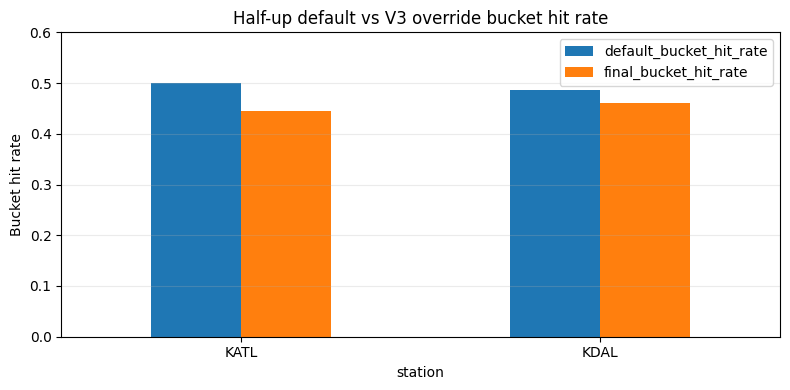

In [7]:
combined = forward_metrics.loc[forward_metrics["period"].eq("2024-2025")]
plot_data = combined.set_index("station")[["default_bucket_hit_rate", "final_bucket_hit_rate"]]
ax = plot_data.plot(kind="bar", figsize=(8, 4), ylim=(0, max(0.6, plot_data.to_numpy().max() + 0.05)))
ax.set_title("Half-up default vs V3 override bucket hit rate")
ax.set_ylabel("Bucket hit rate")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Continuous-residual override baseline


In [8]:
comparison_parts = []
for station, config in STATIONS.items():
    continuous = pd.read_csv(config["continuous"])
    baseline = continuous_override_comparison(
        results[station]["forward_predictions"], continuous
    ).assign(station=station, model="continuous_student_t")
    comparison_parts.append(baseline)
    model = results[station]["forward_metrics"].loc[
        results[station]["forward_metrics"]["period"].eq("2024-2025")
    ].assign(station=station, model="v3_override_classifier")
    comparison_parts.append(model)
continuous_comparison = pd.concat(comparison_parts, ignore_index=True)
continuous_comparison[[
    "station", "model", "binary_log_loss", "brier", "ece", "roc_auc", "pr_auc",
    "default_bucket_hit_rate", "final_bucket_hit_rate", "net_recovered_wins",
]].sort_values(["station", "binary_log_loss"])


,station,model,binary_log_loss,brier,ece,roc_auc,pr_auc,default_bucket_hit_rate,final_bucket_hit_rate,net_recovered_wins
0,KATL,continuous_student_t,0.317565,0.111807,0.059410,0.791029,0.306887,0.499314,0.436214,-46
1,KATL,v3_override_classifier,0.608276,0.188394,0.173330,0.759546,0.246935,0.499314,0.445816,-39
2,KDAL,continuous_student_t,0.305782,0.108119,0.038824,0.817270,0.392731,0.486264,0.478022,-6
3,KDAL,v3_override_classifier,0.334915,0.114786,0.069792,0.810088,0.392895,0.486264,0.461538,-18


## Exploratory 2026


In [9]:
holdout_predictions, holdout_rows = {}, []
for station, config in STATIONS.items():
    source = sources[station]
    test = pd.read_csv(config["pipeline"] / f"{station}_year_split_test_predictions.csv")
    test_point = test.loc[test["method"].eq("ridge_stack"), ["contract_date", "actual_high_f", "predicted_high_f"]]
    all_point = pd.concat([source["point"][["contract_date", "actual_high_f", "predicted_high_f"]], test_point], ignore_index=True)
    all_base = pd.concat([source["validation"], test], ignore_index=True)
    all_frame = build_round_override_frame(
        source["features"], all_point, all_base, include_peak_features=config["peak"]
    )
    holdout = all_frame.loc[all_frame["year"].eq(2026)]
    predicted = predict_round_override(results[station]["final_state"], holdout)
    holdout_predictions[station] = predicted
    holdout_rows.append({"station": station, **round_override_metrics(predicted)})
holdout_metrics = pd.DataFrame(holdout_rows)
holdout_metrics[[
    "station", "count", "binary_log_loss", "ece", "default_bucket_hit_rate",
    "final_bucket_hit_rate", "bucket_hit_rate_lift", "override_count",
    "override_precision", "recovered_losses", "damaged_wins", "net_recovered_wins",
]]


D:\dev\weather-research\src\calibration\round_direction.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["floor_degree_f"] = floor_degree
D:\dev\weather-research\src\calibration\round_direction.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["ceil_degree_f"] = ceil_degree
D:\dev\weather-research\src\calibration\round_direction.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

D:\dev\weather-research\src\calibration\round_override.py:123: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["fraction_distance_to_half_f"] = (
D:\dev\weather-research\src\calibration\round_override.py:149: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["models_supporting_default_bucket"] = default_support
D:\dev\weather-research\src\calibration\round_override.py:150: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

,station,count,binary_log_loss,ece,default_bucket_hit_rate,final_bucket_hit_rate,bucket_hit_rate_lift,override_count,override_precision,recovered_losses,damaged_wins,net_recovered_wins
0,KATL,172,0.417942,0.096451,0.465116,0.465116,0.000000,0,NaN,0,0,0
1,KDAL,170,0.334879,0.097376,0.482353,0.464706,-0.017647,28,0.285714,8,11,-3


## Executable V3 audit


In [10]:
audit_parts = []
for station, config in STATIONS.items():
    audit_parts.append(
        audit_round_override_system(
            frames[station], results[station], include_peak_features=config["peak"]
        ).assign(station=station)
    )
    frame = frames[station]
    audit_parts.append(pd.DataFrame([
        {"station": station, "audit": "unique_station_dates", "passed": not frame["contract_date"].duplicated().any(), "detail": f"duplicates={int(frame['contract_date'].duplicated().sum())}"},
        {"station": station, "audit": "integer_settlement_labels", "passed": bool(np.allclose(frame["actual_high_f"], np.round(frame["actual_high_f"]))), "detail": f"rows={len(frame)}"},
    ]))
audit_report = pd.concat(audit_parts, ignore_index=True)[["station", "audit", "passed", "detail"]]
display(audit_report)
failed = audit_report.loc[~audit_report["passed"]]
assert failed.empty, failed.to_dict(orient="records")
print(f"All {len(audit_report)} V3 audits passed")


,station,audit,passed,detail
0,KATL,default_is_half_up,True,default degree equals honest point half-up degree
1,KATL,alternative_is_opposite_floor_ceil,True,opposite of default floor/ceil choice
2,KATL,actionable_formula,True,alternative and default buckets differ
3,KATL,override_target_formula,True,alternative wins and default loses
4,KATL,non_actionable_targets_are_zero,True,same-bucket floor/ceil rows cannot request ove...
5,KATL,all_outer_rows_scored,True,outer_rows=729
6,KATL,override_only_when_actionable,True,no meaningless same-bucket overrides
7,KATL,chronological_fit_calibration_policy_validation,True,fit < calibration < policy < outer validation
8,KATL,win_accounting_identity,True,final-default equals recovered-damaged
9,KATL,kdal_no_peak_contract,True,peak_overlap=29


All 28 V3 audits passed


## Export V3 research artifacts


In [11]:
OUTPUT_ROOT = PROJECT_ROOT / "data/calibration/station_round_override_v3"
exports = []
for station, result in results.items():
    output, weights = OUTPUT_ROOT / station, OUTPUT_ROOT / station / "model_weights"
    weights.mkdir(parents=True, exist_ok=True)
    result["forward_predictions"].to_csv(output / f"{station}_v3_forward_predictions.csv", index=False)
    result["forward_metrics"].to_csv(output / f"{station}_v3_forward_metrics.csv", index=False)
    result["fold_states"].to_csv(output / f"{station}_v3_fold_states.csv", index=False)
    result["tuning"].to_csv(output / f"{station}_v3_inner_tuning.csv", index=False)
    result["threshold_tuning"].to_csv(output / f"{station}_v3_threshold_tuning.csv", index=False)
    holdout_predictions[station].to_csv(output / f"{station}_v3_2026_predictions.csv", index=False)
    bundle = weights / f"{station}_half_up_override_classifier_v3.joblib"
    joblib.dump(serializable_override_bundle(result), bundle)
    exports.append({"station": station, "bundle": str(bundle), "final_family": result["final_state"]["selected_spec"].family, "final_threshold": result["final_state"]["override_threshold"]})
audit_report.to_csv(OUTPUT_ROOT / "v3_audit.csv", index=False)
dataset_summary.to_csv(OUTPUT_ROOT / "dataset_summary.csv", index=False)
continuous_comparison.to_csv(OUTPUT_ROOT / "continuous_baseline_comparison.csv", index=False)
holdout_metrics.to_csv(OUTPUT_ROOT / "exploratory_2026_metrics.csv", index=False)
pd.DataFrame(exports)


,station,bundle,final_family,final_threshold
0,KATL,D:\dev\weather-research\data\calibration\stati...,logistic,0.475
1,KDAL,D:\dev\weather-research\data\calibration\stati...,catboost,0.500


## Acceptance rule

V3 is accepted only if it produces positive net recovered wins and bucket-hit lift in each honest
outer year without materially worse probability calibration than the continuous baseline. A small
exploratory 2026 gain cannot override a negative 2024 or 2025 result.
